#### Import Libraries

In this section, we import all the necessary Python libraries required for data analysis and visualization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the loan approval dataset into a pandas DataFrame
df = pd.read_csv(r'C:\Users\rehan\OneDrive\Desktop\Data Science\6-Months-Data-Science\loan approval project\data cleaning\loan_approval.csv')

In [3]:
# Preview the dataset
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [4]:
# Remove non-essential columns for data analysis
df.drop(['city', 'name'], axis=1, inplace=True)

In [5]:
# Preview the dataset after removing unnecessary columns
df

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,False
1,44592,729,15446,28,55.0,False
2,33278,584,11189,13,45.0,False
3,127196,344,48823,29,50.0,False
4,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,True
1996,38799,635,48259,17,40.0,False
1997,41957,763,16752,5,60.0,True
1998,139022,360,24031,35,55.0,False


In [6]:
# Check the unique values in the target column
df['loan_approved'].unique()

array([False,  True])

In [7]:
# Create a mapping dictionary for the target variable
loan_approved_dict = {True: 1, False: 0}

In [8]:
# Convert the target variable into binary values
df['loan_approved'] = df['loan_approved'].map(loan_approved_dict)

In [9]:
# Verify the binary values in the target column
df['loan_approved'].unique()

array([0, 1])

In [10]:
# Preview the updated dataset
df

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,0
1,44592,729,15446,28,55.0,0
2,33278,584,11189,13,45.0,0
3,127196,344,48823,29,50.0,0
4,66048,496,47174,4,25.0,0
...,...,...,...,...,...,...
1995,92163,770,12251,13,85.0,1
1996,38799,635,48259,17,40.0,0
1997,41957,763,16752,5,60.0,1
1998,139022,360,24031,35,55.0,0


In [11]:
# Create the feature matrix by removing the target column
x = df.drop(['loan_approved'], axis=1)

In [12]:
# Preview the feature matrix
x

,income,credit_score,loan_amount,years_employed,points
0,113810,389,39698,27,50.0
1,44592,729,15446,28,55.0
2,33278,584,11189,13,45.0
3,127196,344,48823,29,50.0
4,66048,496,47174,4,25.0
...,...,...,...,...,...
1995,92163,770,12251,13,85.0
1996,38799,635,48259,17,40.0
1997,41957,763,16752,5,60.0
1998,139022,360,24031,35,55.0


In [13]:
# Create the target variable
y = df['loan_approved']

In [14]:
# Preview the target variable
y

0       0
1       0
2       0
3       0
4       0
       ..
1995    1
1996    0
1997    1
1998    0
1999    0
Name: loan_approved, Length: 2000, dtype: int64

In [15]:
# Check the dimensions of the dataset
df.shape

(2000, 6)

In [16]:
# Preview the first five rows of the dataset
df.head()

,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810,389,39698,27,50.0,0
1,44592,729,15446,28,55.0,0
2,33278,584,11189,13,45.0,0
3,127196,344,48823,29,50.0,0
4,66048,496,47174,4,25.0,0


In [17]:
# Preview the last five rows of the dataset
df.tail()

,income,credit_score,loan_amount,years_employed,points,loan_approved
1995,92163,770,12251,13,85.0,1
1996,38799,635,48259,17,40.0,0
1997,41957,763,16752,5,60.0,1
1998,139022,360,24031,35,55.0,0
1999,41188,482,31397,6,20.0,0


In [18]:
# Display the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   income          2000 non-null   int64  
 1   credit_score    2000 non-null   int64  
 2   loan_amount     2000 non-null   int64  
 3   years_employed  2000 non-null   int64  
 4   points          2000 non-null   float64
 5   loan_approved   2000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 93.9 KB


In [19]:
# Display the statistical summary of the dataset
df.describe()

,income,credit_score,loan_amount,years_employed,points,loan_approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000,0.43950
std,34487.874907,160.564945,14207.320147,11.777813,18.638033,0.49645
min,30053.000000,300.000000,1022.000000,0.000000,10.000000,0.00000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000,0.00000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000,0.00000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000,1.00000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000,1.00000


In [20]:
# Check for missing values in each column
df.isnull().sum()

income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

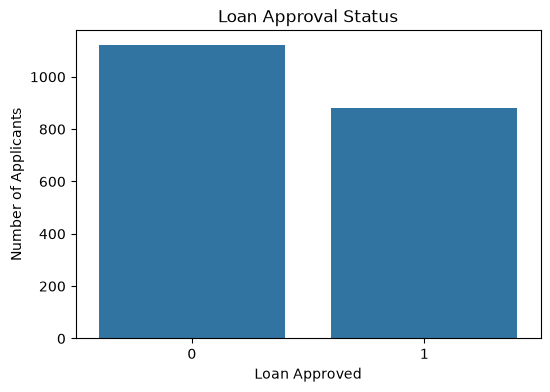

In [21]:
# Visualize the distribution of loan approval status

plt.figure(figsize=(6, 4))

sns.countplot(x='loan_approved', data=df)   # create a count plot

plt.title("Loan Approval Status")
plt.xlabel("Loan Approved")
plt.ylabel("Number of Applicants")

plt.show()

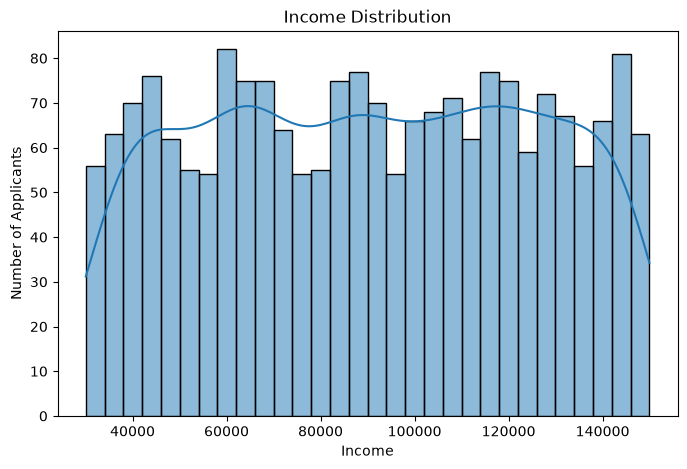

In [22]:
# Visualize the distribution of applicants' income

plt.figure(figsize=(8, 5))

sns.histplot(df['income'], bins=30, kde=True)   # create a histogram with kernel density estimate

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Applicants")

plt.show()

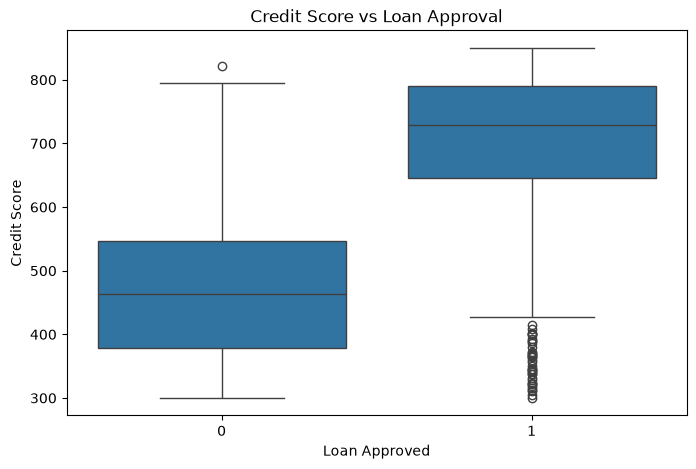

In [23]:
# Compare credit score distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='credit_score', data=df)  # box plot comparing credit score on loan approval status

plt.title("Credit Score vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")

plt.show()

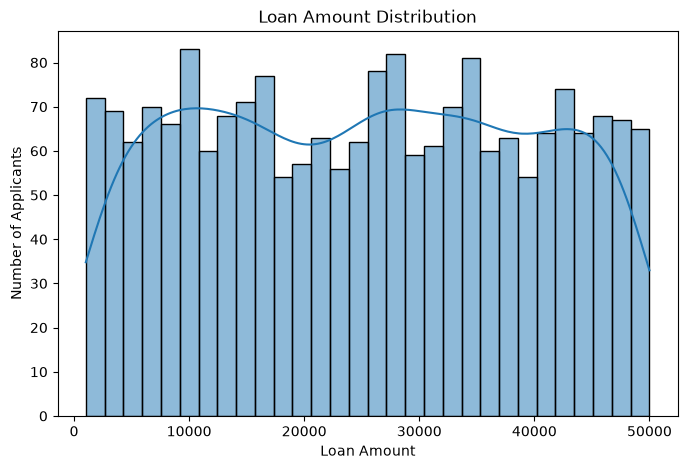

In [24]:
# Visualize the distribution of loan amounts

plt.figure(figsize=(8, 5))

sns.histplot(df['loan_amount'], bins=30, kde=True) 

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")

plt.show()

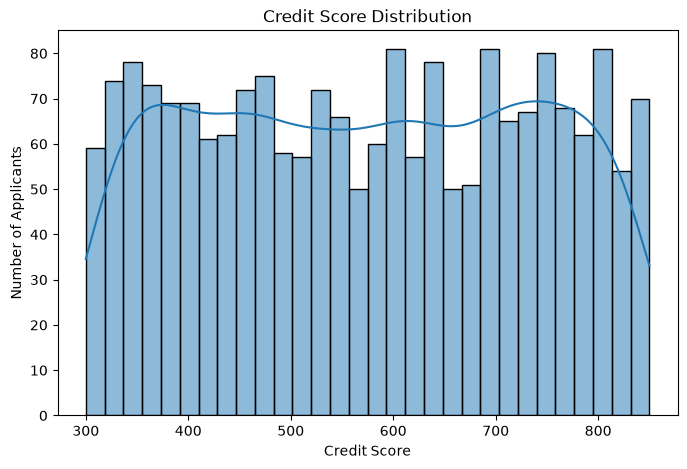

In [25]:
# Visualize the distribution of applicants' credit scores

plt.figure(figsize=(8, 5))

sns.histplot(df['credit_score'], bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Applicants")

plt.show()

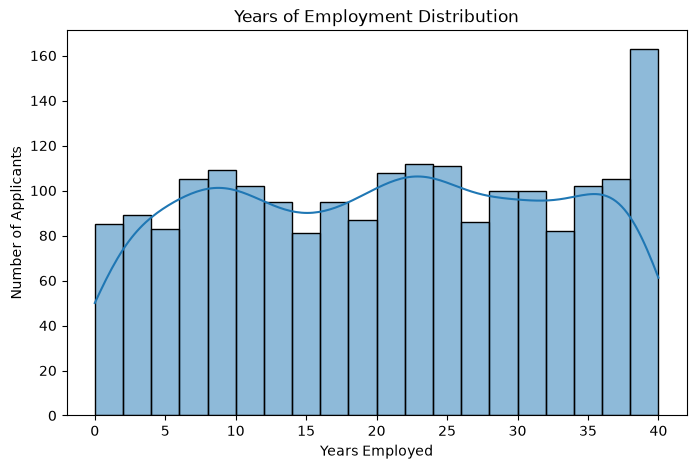

In [26]:
# Visualize the distribution of years of employment

plt.figure(figsize=(8, 5))

sns.histplot(df['years_employed'], bins=20, kde=True)

plt.title("Years of Employment Distribution")
plt.xlabel("Years Employed")
plt.ylabel("Number of Applicants")

plt.show()

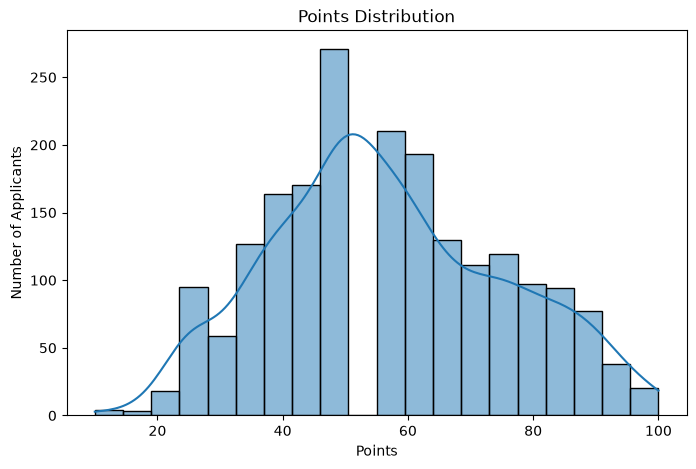

In [27]:
# Visualize the distribution of applicants' points

plt.figure(figsize=(8, 5))

sns.histplot(df['points'], bins=20, kde=True)

plt.title("Points Distribution")
plt.xlabel("Points")
plt.ylabel("Number of Applicants")

plt.show()

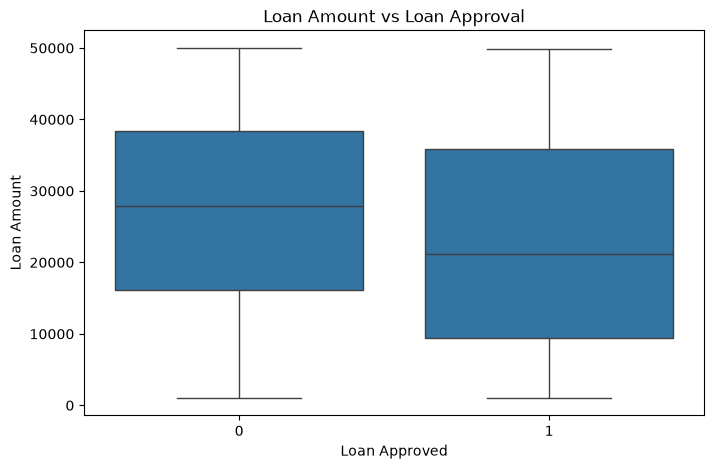

In [28]:
# Compare loan amount distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='loan_amount', data=df)

plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Loan Amount")

plt.show()

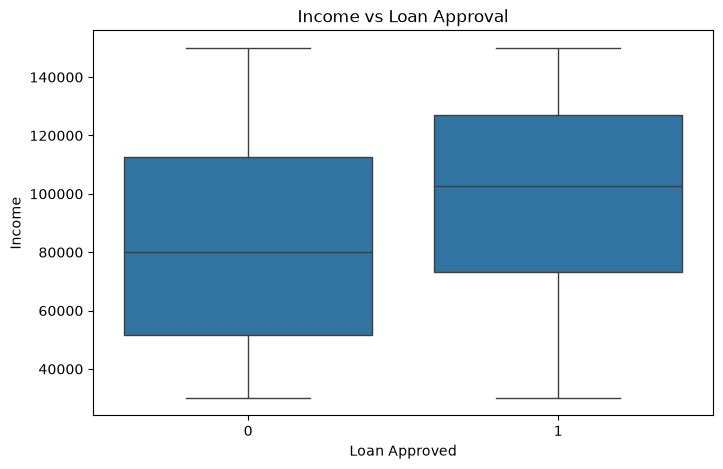

In [29]:
# Compare income distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='income', data=df)

plt.title("Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Income")

plt.show()

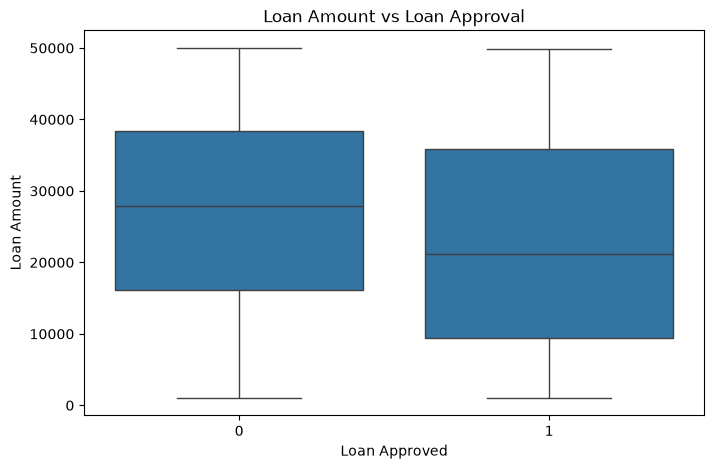

In [30]:
# Compare loan amount distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='loan_amount', data=df)

plt.title("Loan Amount vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Loan Amount")

plt.show()

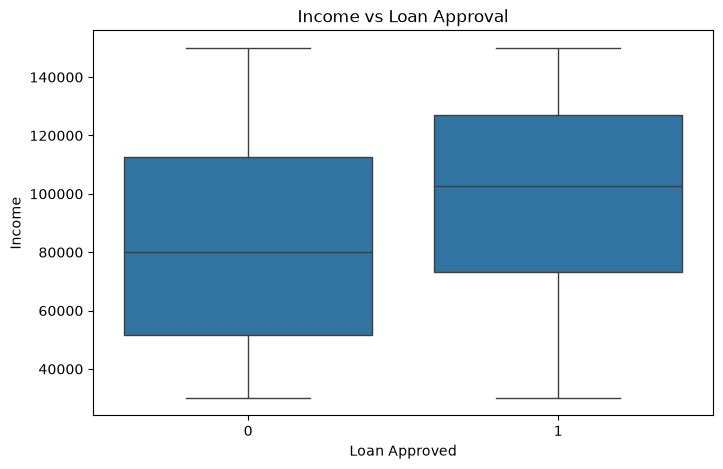

In [31]:
# Compare income distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='income', data=df)

plt.title("Income vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Income")

plt.show()

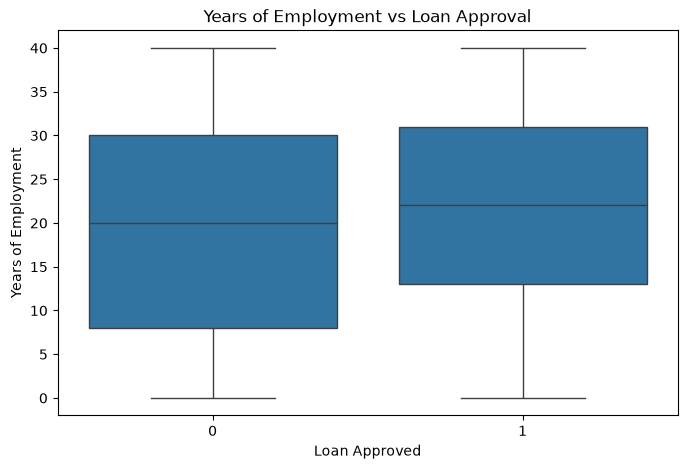

In [32]:
# Compare years of employment across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='years_employed', data=df)

plt.title("Years of Employment vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Years of Employment")

plt.show()

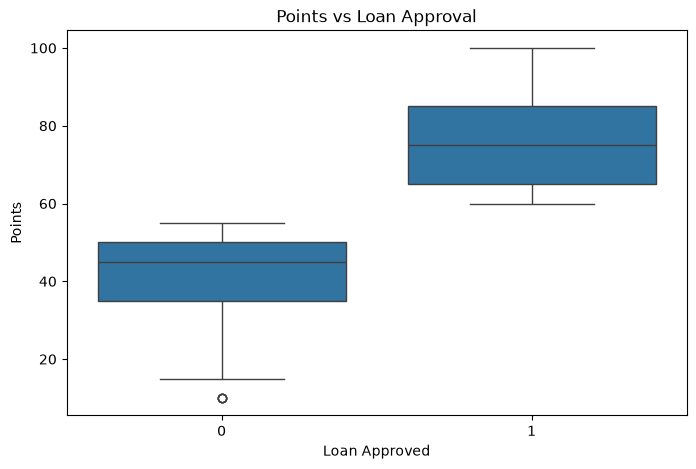

In [33]:
# Compare points distribution across loan approval status

plt.figure(figsize=(8, 5))

sns.boxplot(x='loan_approved', y='points', data=df)

plt.title("Points vs Loan Approval")
plt.xlabel("Loan Approved")
plt.ylabel("Points")

plt.show()

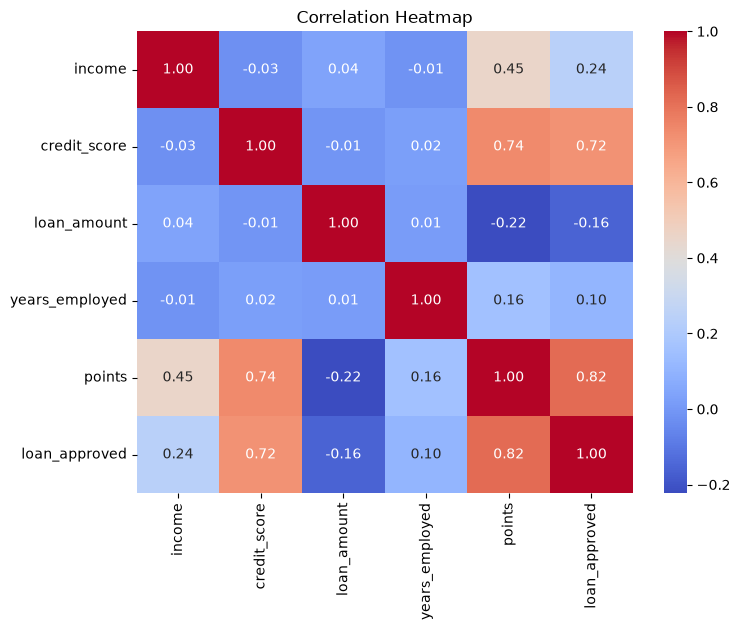

In [34]:
# Visualize the correlation between numerical features

plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

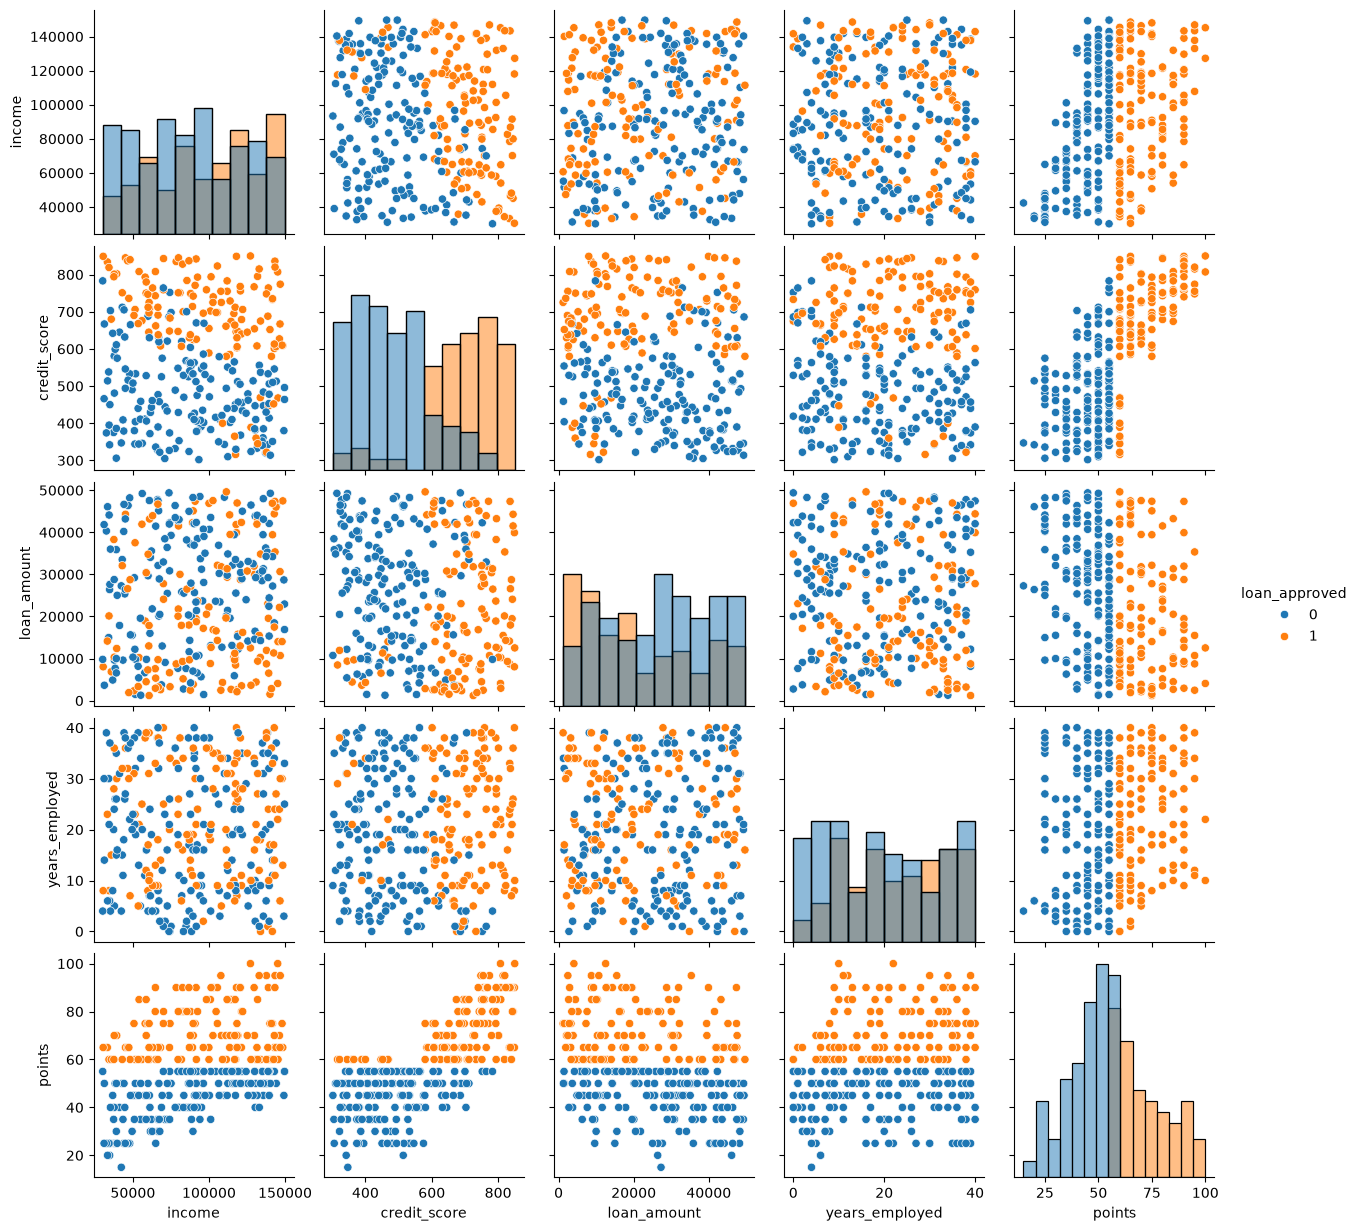

In [35]:
# Visualize pairwise relationships between numerical features

sns.pairplot(
    df.sample(300, random_state=42),
    hue='loan_approved',
    diag_kind='hist'
)

plt.show()

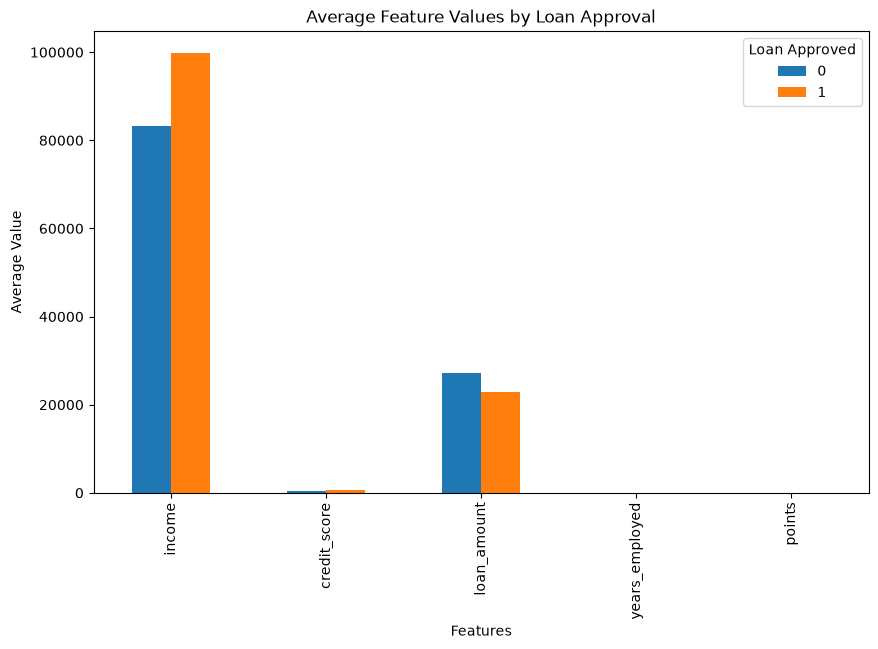

In [36]:
# Compare average feature values for approved vs rejected loans

df.groupby('loan_approved').mean().T.plot(kind='bar', figsize=(10, 6))

plt.title("Average Feature Values by Loan Approval")
plt.xlabel("Features")
plt.ylabel("Average Value")

plt.legend(title="Loan Approved")

plt.show()

## Final Insights from the Data

- Applicants with higher credit scores are more likely to get loan approval.
- Income shows a moderate relationship with loan approval.
- Points and years of employment also influence loan approval probability.
- Loan amount does not show a very strong direct impact on approval.
- Credit score appears to be the most important factor in loan approval.

In [37]:
# Correlation of features with target variable (loan approval)

df.corr(numeric_only=True)['loan_approved'].sort_values(ascending=False)

loan_approved     1.000000
points            0.821415
credit_score      0.715788
income            0.238066
years_employed    0.104408
loan_amount      -0.157859
Name: loan_approved, dtype: float64

In [38]:
# Final check for missing values in dataset

df.isnull().sum().sort_values(ascending=False)

income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [39]:
# Save the cleaned dataset for future use

df.to_csv("cleaned_loan_data.csv", index=False)

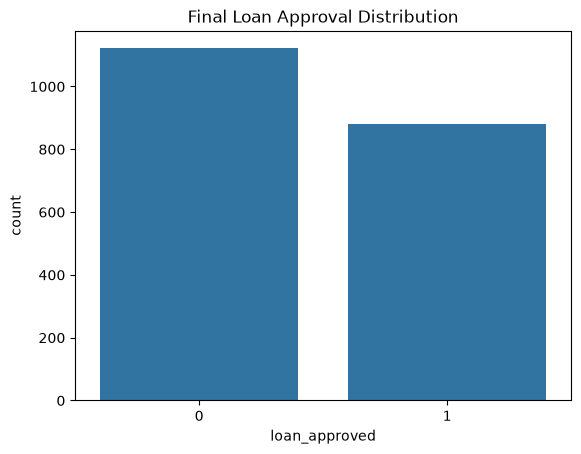

In [40]:
# Final quick view of loan approval distribution

sns.countplot(x='loan_approved', data=df)

plt.title("Final Loan Approval Distribution")
plt.show()

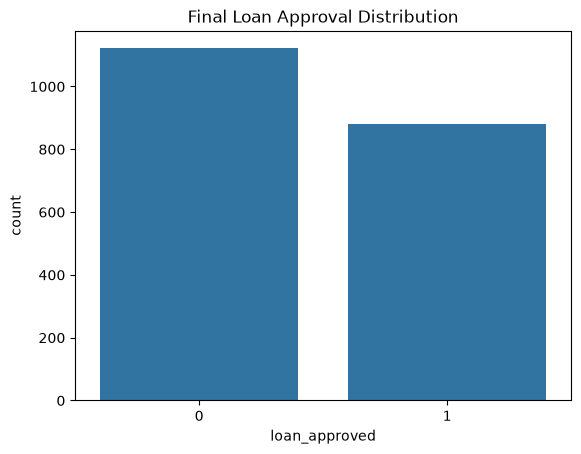

In [41]:
# Final quick view of loan approval distribution

sns.countplot(x='loan_approved', data=df)

plt.title("Final Loan Approval Distribution")
plt.show()